# How many FRET pairs? Greedy site selection (Olga) on a T4 lysozyme ensemble

*Experiment planning after Olga (Dimura et al., Nat. Commun. 11, 5394, 2020):
`IMP.bff.select_probe_pairs`)*

Given an ensemble of candidate structures and a set of labelling pairs that
*could* be measured: which pairs do you measure, and in what order? The greedy
selector repeatedly adds the FRET pair that leaves the smallest **expected RMSD**
between the true structure and the conformer the measurements would single out.

What comes back is an ordered list of pairs and a **decay curve** — the plot
asked for here: **number of FRET pairs vs. the resulting resolution** (expected
mean RMSD in Å). The first pairs buy several ångström each; the curve flattens
once further pairs report on distances the earlier ones already pinned down.

The ensemble is the shipped T4 lysozyme docking trajectory
(`examples/structure/T4L/t4l_docking.rmf3`), the candidate sites come from its
`fret.fps.json` score set.

In [1]:
def example_path(relative):
    """Example data from the installed package, or from this checkout.

    ``IMP.bff.get_example_path`` reads the examples the conda module installs.
    The pip wheel deliberately does not carry them (they are 84 MB against a
    6.6 MB wheel), so it raises, and the notebook then looks for the same file
    in the repository it is running from.
    """
    import pathlib
    try:
        candidate = pathlib.Path(IMP.bff.get_example_path(str(relative)))
        if candidate.exists():
            return str(candidate)
    except Exception:
        pass
    here = pathlib.Path.cwd().resolve()
    for parent in (here, *here.parents):
        candidate = parent / "examples" / relative
        if candidate.exists():
            return str(candidate)
    raise FileNotFoundError(
        f"examples/{relative} is in neither the installed package nor a parent "
        f"of {here}: run this notebook from a checkout, or install the conda "
        f"package imp.bff, which ships the examples."
    )


In [2]:
import numpy as np
import pylab as plt

import RMF
import IMP
import IMP.atom
import IMP.core
import IMP.rmf
import IMP.bff

root = example_path("structure/T4L")
rmf_fn, fps_fn = root + "/t4l_docking.rmf3", root + "/fret.fps.json"


## The ensemble and the candidate pairs

The beads the RMSD is measured over are taken *before* the restraint decorates
the hierarchy with accessible volumes — those move with the dye, not the fold.

In [3]:
m = IMP.Model()
f = RMF.open_rmf_file_read_only(rmf_fn)
hier = IMP.rmf.create_hierarchies(f, m)[0]
IMP.rmf.load_frame(f, RMF.FrameID(0))
beads = [IMP.core.XYZ(p) for p in IMP.atom.get_leaves(hier)]
frames = list(f.get_root_frames())

restraint = IMP.bff.ProbeNetworkRestraint(hier, fps_fn, score_set="chi2_C1_33p")
pair_names = list(restraint.get_pair_names())
print(f"{len(frames)} frames, {len(beads)} beads, {len(pair_names)} candidate pairs")

100 frames, 159 beads, 33 candidate pairs


## One pass over the trajectory collects both inputs

`get_pair_efficiencies` re-evaluates the accessible volumes per frame, so
`effs[frame, pair]` is the mean FRET efficiency of each candidate in each
conformer.

In [4]:
effs = np.empty((len(frames), len(pair_names)))
coords = np.empty((len(frames), len(beads), 3))
for i, frame in enumerate(frames):
    IMP.rmf.load_frame(f, frame)
    effs[i] = restraint.get_pair_efficiencies()
    coords[i] = [b.get_coordinates() for b in beads]

# pairwise RMSD after superposition: the yardstick the selection is scored on
rmsds = IMP.bff.pairwise_rmsd(coords, True)
print(f"RMSD spread {rmsds[np.triu_indices_from(rmsds, 1)].mean():.2f} A mean, "
      f"{rmsds.max():.2f} A max")

RMSD spread 4.76 A mean, 19.90 A max


## The greedy selection

`err` is the expected absolute error of a measured FRET efficiency — the
selector's only notion of what an experiment can resolve. `max_pairs` caps how
far down the ranking to go; here it is deliberately large (25 of 33) so the
saturation of the curve is visible.

In [5]:
ERR, MAX_PAIRS = 0.06, 25
selected, decay = IMP.bff.select_probe_pairs(
    effs, rmsds, measurement_error=ERR, max_pairs=MAX_PAIRS)
selected, decay = np.asarray(selected), np.asarray(decay)

# resolution before any measurement: the expected RMSD on the prior alone
start = IMP.bff.expected_rmsd(
    rmsds.ravel(), np.zeros(rmsds.size), 1, 0.99, len(frames))

print(f"{'#':>2}  {'pair':<14} {'expected RMSD':>13} {'gain':>7}")
print(f"{'-':>2}  {'(no data)':<14} {start:>11.2f} A {'':>7}")
previous = start
for rank, (idx, value) in enumerate(zip(selected, decay), start=1):
    print(f"{rank:>2}  {pair_names[idx]:<14} {value:>11.2f} A {previous - value:>6.2f} A")
    previous = value

 #  pair           expected RMSD    gain
 -  (no data)             4.71 A        
 1  70-132_C1             3.08 A   1.63 A
 2  60-86_C1              2.62 A   0.46 A
 3  22-127_C1             2.34 A   0.28 A
 4  8-86_C1               2.27 A   0.07 A
 5  44-150_C1             2.24 A   0.03 A
 6  60-119_C1             2.19 A   0.05 A
 7  5-132_C1              2.15 A   0.04 A
 8  19-86_C1              2.14 A   0.02 A
 9  55-150_C1             2.14 A   0.00 A
10  70-119_C1             2.12 A   0.01 A
11  36-132_C1             2.12 A   0.00 A
12  60-132_C1             2.12 A  -0.00 A
13  8-119_C1              2.11 A   0.00 A
14  44-119_C1             2.11 A   0.00 A
15  19-132_C1             2.12 A  -0.00 A
16  8-132_C1              2.12 A  -0.01 A
17  44-132_C1             2.13 A  -0.01 A
18  69-119_C1             2.13 A  -0.00 A
19  69-150_C1             2.14 A  -0.01 A
20  19-69_C1              2.14 A   0.00 A
21  69-132_C1             2.14 A  -0.00 A
22  19-119_C1             2.15 A  -0

## Number of FRET pairs vs. resulting resolution

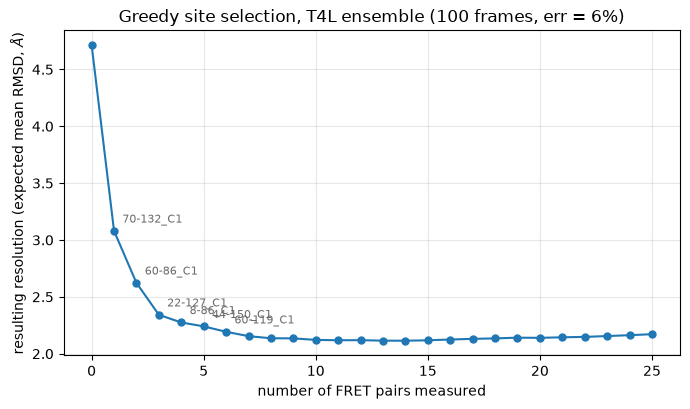

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.2))
n = np.arange(len(decay) + 1)
ax.plot(n, np.concatenate([[start], decay]), "o-", color="#1f77b4", ms=5)

# annotate the first pairs -- where the curve actually moves
for i, name in enumerate([pair_names[j] for j in selected[:6]], start=1):
    ax.annotate(name, (i, decay[i - 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=8, color="dimgray")

ax.set_xlabel("number of FRET pairs measured")
ax.set_ylabel(r"resulting resolution (expected mean RMSD, $\AA$)")
ax.set_title(f"Greedy site selection, T4L ensemble "
             f"({len(frames)} frames, err = {ERR:.0%})")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("greedy_pair_resolution.png", dpi=150)
plt.show()

## Reading the curve

- The **first pair** already cuts the expected RMSD by roughly a factor of two:
  a single measurement discards most of the ensemble.
- Each further pair buys less; after ~8–10 pairs the curve is flat — the
  remaining candidates re-measure separations that are already resolved, and
  with `err = 6%` no candidate can separate conformers that differ by less.
- That flat region is the practical answer to *how many pairs*: measurements
  past the knee cost experiments and buy no resolution.

Step-to-step non-monotonicity is expected and not a bug: the greedy scores each
candidate against the χ² accumulated so far, and the best remaining candidate
can still leave a slightly larger expectation than the step before it.

## Structure is not the whole question: rates too

Olga scores a network by the *structure* it resolves. If the conformers
interconvert, a network is also meant to measure the **rates** between them,
and the two goals are not the same. Two pairs that separate the same pair of
conformers see the same exchange: complementary for the structure, redundant
for the kinetics.

`IMP.bff.ProbeNetworkSelection` is one greedy selector with pluggable scores,
mixed by a weighted sum. Every score is a loss in [0, 1] relative to nothing
measured, so the weights are comparable:

- `ProbeResolutionTerm`: Olga's expected RMSD relative to the prior RMSD;
- `ProbeKineticsTerm`: how well the rates of a kinetic scheme are determined.
  Each pair is its own double mutant on its own molecules, so pairs share the
  rates. Per pair, bursts are simulated, scored by `FRETNetworkModel`, and the
  rate information left after the pair's own state distances are paid for is
  kept (a Schur complement). The loss is the geometric-mean posterior variance
  of the log-rates relative to their prior;
- `ProbeLabellingTerm`: Labelizer site scores and a cost per mutation (see
  `labelizer_greedy_pipeline.ipynb`).

With only the resolution score it is exactly `select_probe_pairs`:

In [7]:
resolution = IMP.bff.ProbeResolutionTerm(effs, rmsds, ERR)
olga = IMP.bff.ProbeNetworkSelection(len(pair_names))
olga.add_term(resolution)
units, losses = olga.select(MAX_PAIRS)
print("same order:", list(units) == list(selected))
print("same decay:", np.allclose(np.asarray(losses) * resolution.get_initial_rmsd(), decay,
                                 rtol=1e-12))

same order: True
same decay: True


### A kinetic scheme over the ensemble

The docking ensemble has no kinetics of its own, so here is a hypothetical one.
Three representative conformers (k-medoids on the RMSD matrix, seeded at the
most distant frames) are the states A, B and C, connected A ⇌ B ⇌ C plus a
slow direct A ⇌ C (rates in 1/ms). Each candidate's distance in each state is
read back from its efficiency in that state's frame. The instrument is one
excitation with two detection channels, bright enough for about 40 photons in
a 2 ms burst.

In [8]:
def kmedoids(d, k):
    idx = [int(np.argmax(d.sum(1)))]
    while len(idx) < k:                      # farthest-point seeding
        idx.append(int(np.argmax(d[:, idx].min(1))))
    idx = np.array(idx)
    for _ in range(50):
        label = np.argmin(d[:, idx], 1)
        new = np.array([np.where(label == c)[0][np.argmin(
            d[np.ix_(label == c, label == c)].sum(1))] for c in range(k)])
        if np.array_equal(new, idx):
            break
        idx = new
    return idx, np.argmin(d[:, idx], 1)


states, members = kmedoids(np.asarray(rmsds), 3)
print("state frames:", states, " frames per state:", np.bincount(members))
print("RMSD between the states (A):\n", np.round(np.asarray(rmsds)[np.ix_(states, states)], 1))

R0 = 52.0
distances = R0 * (1.0 / np.clip(effs[states], 1e-6, 1 - 1e-6) - 1.0) ** (1.0 / 6.0)

process = IMP.bff.FRETHiddenProcess(3)
for i, j, k in [(0, 1, 2.0), (1, 0, 3.0), (1, 2, 1.5), (2, 1, 2.5), (0, 2, 0.5), (2, 0, 0.7)]:
    process.set_rate(i, j, k)

donor = IMP.bff.FRETDye("donor")
donor.add_state("bright", 1.0, 0.8, 4.0)
acceptor = IMP.bff.FRETDye("acceptor")
acceptor.add_state("bright", 1.0, 0.6, 3.0, 1.0)
template = IMP.bff.FRETMeasurement("pair", donor, acceptor, R0)
instrument = IMP.bff.FRETInstrument(
    IMP.bff.PhotophysicsCrosstalkMatrix(["p"], ["donor", "acceptor"], [60.0, 1.0]),
    IMP.bff.PhotophysicsCrosstalkMatrix(["donor", "acceptor"], ["g", "r"],
                                        [0.4, 0.03, 0.05, 0.45]), 1, 0.25)
instrument.set_background(0, 0.5)
instrument.set_background(1, 0.5)
template.set_instrument(instrument)

options = IMP.bff.FRETSimulationOptions()
options.n_molecules, options.duration, options.seed = 300, 2.0, 11
kinetics = IMP.bff.ProbeKineticsTerm(process, template, options=options,
                                     n_bursts_per_pair=1000.0)
kinetics.add_pairs(distances)
print(f"{kinetics.get_n_pairs()} candidates scored for", len(kinetics.get_rate_names()), "rates")

state frames: [ 0 44  4]  frames per state: [ 2 94  4]
RMSD between the states (A):
 [[ 0.  17.4 14.4]
 [17.4  0.   9.1]
 [14.4  9.1  0. ]]


33 candidates scored for 6 rates


### Three selections of four pairs

Resolution only (Olga), rates only, and the two mixed with equal weight.

In [9]:
N_PAIRS = 4
runs = {}
for name, (w_res, w_kin) in [("resolution", (1.0, 0.0)), ("rates", (0.0, 1.0)),
                             ("mixed", (1.0, 1.0))]:
    net = IMP.bff.ProbeNetworkSelection(len(pair_names))
    net.add_term(resolution, w_res)
    net.add_term(kinetics, w_kin)
    picked, _ = net.select(N_PAIRS)
    runs[name] = (list(picked), np.asarray(net.get_term_losses()),
                  max(kinetics.get_rate_sigmas()))

print(f"{'selection':<11} {'expected RMSD':>13} {'rate loss':>9} {'worst sd(ln k)':>14}  pairs")
for name, (picked, lost, worst) in runs.items():
    print(f"{name:<11} {lost[-1, 0] * resolution.get_initial_rmsd():>11.2f} A "
          f"{lost[-1, 1]:>9.4f} {worst:>14.2f}  {', '.join(pair_names[i] for i in picked)}")

selection   expected RMSD rate loss worst sd(ln k)  pairs
resolution         2.27 A    0.0671           1.69  70-132_C1, 60-86_C1, 22-127_C1, 8-86_C1
rates              3.36 A    0.0084           1.05  44-69_C1, 55-119_C1, 19-69_C1, 55-132_C1
mixed              2.35 A    0.0190           1.20  19-69_C1, 70-132_C1, 60-119_C1, 22-127_C1


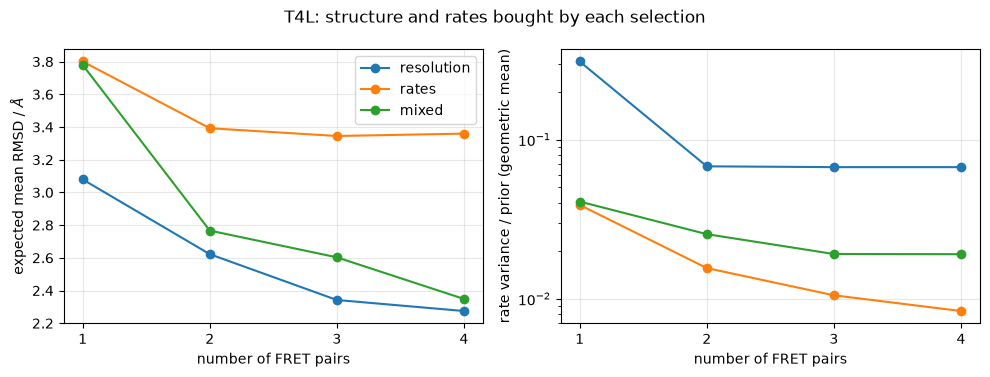

In [10]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(10, 3.8))
for name, (picked, lost, _) in runs.items():
    steps = np.arange(1, len(picked) + 1)
    ax.plot(steps, lost[:, 0] * resolution.get_initial_rmsd(), "o-", label=name)
    bx.plot(steps, lost[:, 1], "o-", label=name)
ax.set_ylabel(r"expected mean RMSD / $\AA$")
bx.set_ylabel("rate variance / prior (geometric mean)")
bx.set_yscale("log")
for a in (ax, bx):
    a.set_xlabel("number of FRET pairs")
    a.set_xticks(range(1, N_PAIRS + 1))
    a.grid(alpha=0.3)
ax.legend()
fig.suptitle("T4L: structure and rates bought by each selection")
fig.tight_layout()
fig.savefig("greedy_pair_structure_and_rates.png", dpi=150)
plt.show()

### Reading the comparison

- **Olga's pairs resolve the structure and leave the rates open.** Its four
  pairs reach 2.27 Å, but the rate variance stays at 0.067 of the prior: they
  report on the same few exchanges.
- **Rates alone buy the rates and give up the structure**: 0.0084 of the prior
  rate variance, 8× below Olga, but 3.36 Å. The pairs that follow the
  exchanges best are not the ones that single out a conformer.
- **The mix keeps nearly all of Olga's structural precision** (2.35 Å, 0.08 Å
  worse) and cuts the rate variance 3.5× (0.019). The weights are the dial;
  both losses are reported at every step, so the price of each is visible.

The kinetic scheme here is invented, so the numbers illustrate the trade, not
T4 lysozyme. With a real scheme (states from a Markov model of the ensemble,
rates from a prior experiment or a guess with a broad prior) the same
comparison applies.